# Caso 4 — Avaliação Quantitativa

Avaliamos o Modelo Vetorial (Caso 2) e o BM25 (Caso 3) com as métricas
Precision@10, Recall@10 e MAP (obrigatórias), além de F1@10, MRR e
NDCG@10 (adicionais). Seguindo o enunciado: um documento é considerado
relevante (para as métricas binárias) quando seu grau de relevância no
qrels é **>= 1**; grau **-1** e documentos não julgados contam como não
relevantes. Para o NDCG, a escala do Cranfield é **invertida** antes do cálculo
(`5 - r`, em `build_graded_relevance`), porque na coleção o grau **1 é o
mais relevante** e o 4 o de interesse mínimo. Sem a inversão, o ganho do
NDCG premiaria os documentos menos relevantes.

Os resultados são mantidos **por consulta** (tabela completa) e
**agregados** (média), conforme pedido.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.vector_model import VectorSpaceModel
from src.bm25 import BM25
from src.metrics import evaluate_model

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")

CONFIG = "stopwords_stemming"
doc_tokens = preprocessed[CONFIG]["docs"]
query_tokens_list = preprocessed[CONFIG]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()

RESULTS_DIR = project_root / "data" / "processed"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Rankings completos para as 225 consultas

In [2]:
# Construção dos dois modelos e ranking de TODAS as 225 consultas
#
# Cada ranking cobre toda a coleção, com 1400 documentos, e não apenas o
# Top 10. Isso é necessário para que Recall e MAP sejam calculados
# corretamente. Caso contrário, documentos relevantes fora do Top 10
# seriam tratados como nunca recuperados em vez de recuperados em uma
# posição baixa, que é a situação real. O Caso 9, de análise de erros,
# precisa poder identificar essa diferença.
vsm = VectorSpaceModel(doc_tokens)
bm25 = BM25(doc_tokens, k1=1.2, b=0.75)

vsm_rankings, bm25_rankings = {}, {}
for qid, qtoks in zip(query_ids, query_tokens_list):
    vsm_rankings[qid] = [doc_ids[i] for i, _ in vsm.rank(qtoks)]
    bm25_rankings[qid] = [doc_ids[i] for i, _ in bm25.rank(qtoks)]

print(f"Rankings completos calculados para {len(query_ids)} consultas x 2 modelos.")

Rankings completos calculados para 225 consultas x 2 modelos.


## Métricas por consulta

In [3]:
# Avaliação por consulta: Precision@10, Recall@10, MAP (AP por consulta),
# F1@10, MRR e NDCG@10 (estas três últimas como métricas adicionais)
K = 10
vsm_eval = evaluate_model(vsm_rankings, df_qrels, k=K)
bm25_eval = evaluate_model(bm25_rankings, df_qrels, k=K)

print("Métricas por consulta — Modelo Vetorial (5 primeiras linhas):")
display(vsm_eval.head())
print("\nMétricas por consulta — BM25 (5 primeiras linhas):")
display(bm25_eval.head())

Métricas por consulta — Modelo Vetorial (5 primeiras linhas):


,precision@10,recall@10,AP,F1@10,MRR,ndcg@10,n_relevant
query_id,,,,,,,
1,0.6,0.214286,0.312209,0.315789,1.0,0.446821,28
2,0.4,0.166667,0.223053,0.235294,1.0,0.695412,24
3,0.7,0.875000,0.684722,0.777778,0.5,0.738886,8
4,0.1,0.500000,0.583333,0.166667,1.0,0.613147,2
5,0.2,0.500000,0.243711,0.285714,0.5,0.381947,4



Métricas por consulta — BM25 (5 primeiras linhas):


,precision@10,recall@10,AP,F1@10,MRR,ndcg@10,n_relevant
query_id,,,,,,,
1,0.3,0.107143,0.230600,0.157895,1.0,0.266644,28
2,0.4,0.166667,0.214046,0.235294,1.0,0.637034,24
3,0.7,0.875000,0.661120,0.777778,0.5,0.740380,8
4,0.1,0.500000,0.529412,0.166667,1.0,0.613147,2
5,0.3,0.750000,0.412346,0.428571,0.5,0.607528,4


## Métricas agregadas

In [4]:
# Métricas agregadas (média sobre as 225 consultas)
agg = pd.DataFrame({
    "Modelo Vetorial": vsm_eval.drop(columns="n_relevant").mean(),
    "BM25": bm25_eval.drop(columns="n_relevant").mean(),
})
agg.index.name = "Métrica"
display(agg.round(4))

,Modelo Vetorial,BM25
Métrica,,
precision@10,0.2418,0.2342
recall@10,0.3987,0.3921
AP,0.3015,0.3106
F1@10,0.2712,0.2650
MRR,0.5284,0.5455
ndcg@10,0.3497,0.3557


## Distribuição de desempenho por consulta

A média agregada esconde a variabilidade entre consultas. O histograma
abaixo mostra que ambos os modelos têm uma quantidade considerável de
consultas com AP muito baixo, perto de 0, e um grupo menor com AP alto,
perto de 1, em vez de uma distribuição concentrada em torno da média.
Essa variabilidade é explorada em detalhe nos Casos 5 e 6.

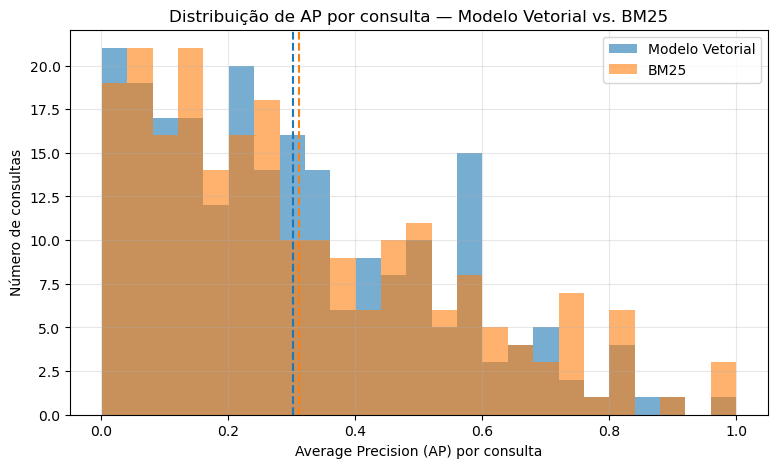

In [5]:
# Distribuição de Average Precision (AP) por consulta, para cada modelo
plt.figure(figsize=(9, 5))
plt.hist(vsm_eval["AP"], bins=25, alpha=0.6, label="Modelo Vetorial")
plt.hist(bm25_eval["AP"], bins=25, alpha=0.6, label="BM25")
plt.axvline(vsm_eval["AP"].mean(), color="C0", linestyle="--", linewidth=1.5)
plt.axvline(bm25_eval["AP"].mean(), color="C1", linestyle="--", linewidth=1.5)
plt.xlabel("Average Precision (AP) por consulta")
plt.ylabel("Número de consultas")
plt.title("Distribuição de AP por consulta — Modelo Vetorial vs. BM25")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Persistência dos resultados

In [6]:
# Persistindo os resultados para reuso nos Casos 5, 6 e 9 (evita
# reconstruir os modelos e garante que todas as análises seguintes usem
# EXATAMENTE os mesmos rankings desta avaliação).
vsm_eval.to_csv(RESULTS_DIR / "vsm_perquery.csv")
bm25_eval.to_csv(RESULTS_DIR / "bm25_perquery.csv")
with open(RESULTS_DIR / "vsm_rankings.pkl", "wb") as f:
    pickle.dump(vsm_rankings, f)
with open(RESULTS_DIR / "bm25_rankings.pkl", "wb") as f:
    pickle.dump(bm25_rankings, f)
print("Resultados salvos em", RESULTS_DIR)

Resultados salvos em C:\Users\amand\OneDrive\Documentos\GitHub\cranfield-info-retrieval\data\processed
